In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Rescaling, Flatten
from tensorflow.keras.callbacks import EarlyStopping

2023-12-31 15:11:57.828058: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2023-12-31 15:11:58.328221: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2023-12-31 15:11:58.328401: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2023-12-31 15:11:58.438369: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-12-31 15:11:58.669259: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2023-12-31 15:11:58.671969: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [4]:
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.layers import RandomZoom, RandomFlip, RandomRotation

In [5]:
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow import expand_dims

In [6]:
data_path = '/home/alvaro/tf_templates/DATA/cell_images'

In [7]:
class_names = os.listdir(data_path)
class_names

['Uninfected', 'Parasitized']

In [8]:
len(os.listdir(data_path + '/' + class_names[0]))

13779

In [9]:
len(os.listdir(data_path + '/' + class_names[1]))

13779

In [10]:
parasitized_cell = data_path + '/' + class_names[0] + '/' + os.listdir(data_path + '/' + class_names[0] + '/')[0]

In [11]:
parasitized_cell_img = imread(parasitized_cell)

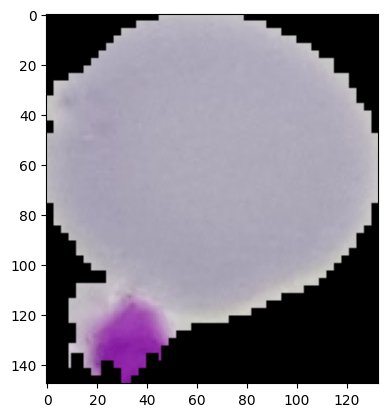

In [12]:
plt.imshow(parasitized_cell_img);

In [13]:
parasitized_cell_img.shape

(148, 133, 3)

In [14]:
uninfected_cell = data_path + '/' + class_names[1] + '/' + os.listdir(data_path + '/' + class_names[1] + '/')[0]

In [15]:
uninfected_cell_img = imread(uninfected_cell)

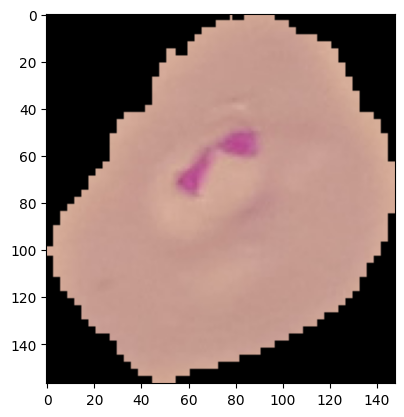

In [16]:
plt.imshow(uninfected_cell_img);

In [17]:
uninfected_cell_img.shape

(157, 148, 3)

In [18]:
dim1 = []
dim2 = []
for image_filename in os.listdir(data_path + '/' + class_names[0]):

    img = imread(data_path + '/' + class_names[0] + '/' + image_filename)
    d1,d2,colors = img.shape
    dim1.append(d1)
    dim2.append(d2)

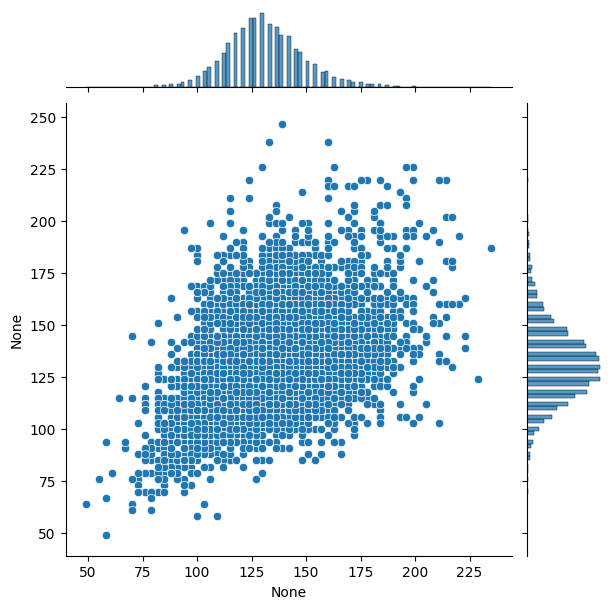

In [19]:
sns.jointplot(x=dim1,y=dim2);

In [20]:
np.mean(dim1)

131.58001306335728

In [21]:
np.mean(dim2)

131.3424776834313

In [22]:
img_height = 134
img_width = 134
colors = 3

In [23]:
batch_size = 32

In [24]:
train_ds = image_dataset_from_directory(
    directory=data_path,
    batch_size=batch_size,
    image_size=(img_height,img_width),
    seed=101,
    validation_split=0.3,
    subset='training'
)

Found 27558 files belonging to 2 classes.
Using 19291 files for training.


In [25]:
val_ds = image_dataset_from_directory(
    directory=data_path,
    batch_size=batch_size,
    image_size=(img_height,img_width),
    seed=101,
    validation_split=0.3,
    subset='validation'
)

Found 27558 files belonging to 2 classes.
Using 8267 files for validation.


In [26]:
data_augmentation = Sequential([
    RandomFlip('horizontal_and_vertical', input_shape=(img_height,img_width,colors)),
    RandomRotation(0.2),
    RandomZoom(0.1)
])

In [27]:
parasitized_cell_img.max()

0.84313726

In [28]:
model = Sequential()

model.add(data_augmentation)
# model.add(Rescaling(1.0/255))
model.add(Conv2D(filters=16, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPool2D())
model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPool2D())
model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPool2D())
model.add(Dropout(0.5))
model.add(Flatten())
model.add(Dense(units=128, activation='relu'))
model.add(Dense(units=2, activation='softmax'))

In [29]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [30]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 134, 134, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 134, 134, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2  (None, 67, 67, 16)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 67, 67, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 33, 33, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 33, 33, 64)       

In [31]:
early_stop = EarlyStopping(monitor='val_loss', patience=1)

In [32]:
model.fit(train_ds, epochs=5, callbacks=[early_stop], validation_data=val_ds)

Epoch 1/5
603/603 [==============================] - 244s 402ms/step - loss: 1.8435 - accuracy: 0.6096 - val_loss: 0.5749 - val_accuracy: 0.7149
Epoch 2/5
603/603 [==============================] - 244s 405ms/step - loss: 0.6434 - accuracy: 0.6301 - val_loss: 0.3117 - val_accuracy: 0.8969
Epoch 3/5
603/603 [==============================] - 231s 384ms/step - loss: 0.2835 - accuracy: 0.9096 - val_loss: 0.2046 - val_accuracy: 0.9363
Epoch 4/5
603/603 [==============================] - 227s 376ms/step - loss: 0.2390 - accuracy: 0.9204 - val_loss: 0.2047 - val_accuracy: 0.9392


In [33]:
losses = pd.DataFrame(model.history.history)

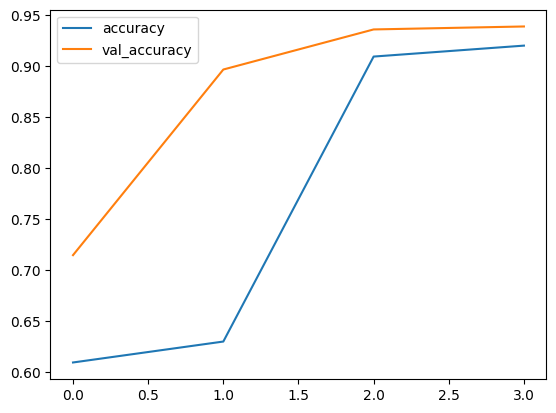

In [34]:
losses[['accuracy','val_accuracy']].plot();

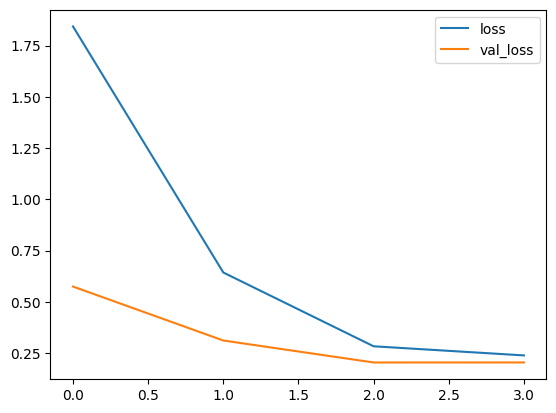

In [35]:
losses[['loss','val_loss']].plot();

In [41]:
parasitized_cell = data_path + '/' + class_names[0] + '/' + os.listdir(data_path + '/' + class_names[0] + '/')[0]

img = load_img(parasitized_cell, target_size=(img_height,img_width))
img_array = img_to_array(img)
img_array = expand_dims(img_array, 0)

In [42]:
prediction = model.predict(img_array)

1/1 [==============================] - 0s 34ms/step


In [43]:
predicted_class = np.argmax(prediction)
confidence = np.max(prediction)

In [44]:
print(f'This image belongs to {class_names[predicted_class]} with a {np.floor(confidence*1e4)/100}% of condifence.')

This image belongs to Uninfected with a 57.06% of condifence.


In [40]:
model.save('/home/alvaro/tf_templates/DATA/malaria_model.keras')